In [1]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split

# 记录开始时间
start_time = time.time()

# 定义超参数
batch_size = 64
learning_rate = 0.001
num_epochs = 100

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
image_datasets = datasets.ImageFolder(data_dir, data_transforms)

# 划分训练集和测试集
train_data, test_data = train_test_split(image_datasets, test_size=0.3, random_state=42)

dataloaders = {'train':torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4),
               'val':torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)}
dataset_sizes = {'train': len(train_data),'val': len(test_data)}

In [2]:
model = models.vgg11(pretrained=True)
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), 
                      lr=learning_rate, momentum=0.9)

# 训练模型
result = {
          "acu_train": [],
          "acu_test": [],
          "loss_train":[],
          "recall": []
          }
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            
#             print(phase,'epoch',":",epoch,'num_imputs',inputs.size())
#             tensor = inputs[0].to(torch.float32).cpu()
#             print(labels[0])
#             # 将张量转换为图像并显示
#             plt.imshow(tensor.permute(1, 2, 0))
#             plt.show()
            
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        
        if phase=='train':
            result["acu_train"].append('{:.4f}'.format(epoch_acc))
            result["loss_train"].append('{:.4f}'.format(epoch_loss))
        elif phase=='val':
            result["acu_test"].append('{:.4f}'.format(epoch_acc))
            recall = recall_score(labels.data.detach().cpu().numpy(), preds.detach().cpu().numpy(), average="macro")
            result["recall"].append(recall)

        print('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}'.format(epoch, phase, epoch_loss, epoch_acc))
        with open('C:/Users/WHS/Desktop/Dual-ResNet18-SVM/result/result_file_VGG11.txt', "a") as file:
            file.write('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}\n'.format(epoch, phase, epoch_loss, epoch_acc))

epoch: 0, train Loss: 1.3750 Acc: 0.3333
epoch: 0, val Loss: 1.1515 Acc: 0.4550
epoch: 1, train Loss: 1.0790 Acc: 0.5484
epoch: 1, val Loss: 0.9194 Acc: 0.5856
epoch: 2, train Loss: 0.8358 Acc: 0.6764
epoch: 2, val Loss: 1.1696 Acc: 0.4595
epoch: 3, train Loss: 0.9323 Acc: 0.6240
epoch: 3, val Loss: 0.7479 Acc: 0.7387
epoch: 4, train Loss: 0.6941 Acc: 0.7500
epoch: 4, val Loss: 0.5347 Acc: 0.8063
epoch: 5, train Loss: 0.4671 Acc: 0.7984
epoch: 5, val Loss: 0.9431 Acc: 0.6441
epoch: 6, train Loss: 0.6565 Acc: 0.7578
epoch: 6, val Loss: 0.5173 Acc: 0.8108
epoch: 7, train Loss: 0.4805 Acc: 0.8411
epoch: 7, val Loss: 0.3751 Acc: 0.8649
epoch: 8, train Loss: 0.3153 Acc: 0.8760
epoch: 8, val Loss: 0.3199 Acc: 0.8874
epoch: 9, train Loss: 0.2389 Acc: 0.9186
epoch: 9, val Loss: 0.2151 Acc: 0.9324
epoch: 10, train Loss: 0.1331 Acc: 0.9516
epoch: 10, val Loss: 0.3266 Acc: 0.8874
epoch: 11, train Loss: 0.1556 Acc: 0.9438
epoch: 11, val Loss: 0.2815 Acc: 0.8964
epoch: 12, train Loss: 0.1170 Acc: 0

In [3]:
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time)

684.5215895175934


In [4]:
torch.save(model.state_dict(), 'VGG11.pth')

In [1]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms) for x in ['train', 'val']}
test_loader = torch.utils.data.DataLoader(image_datasets['val'], batch_size=64, shuffle=True, num_workers=4)

model = models.vgg11()
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 加载之前保存的模型参数
model.load_state_dict(torch.load('VGG11.pth'))

start_time = time.time()
for inputs, labels in test_loader:    
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    print(labels,preds)
    break
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time/len(labels))

tensor([1, 1, 0, 0, 3, 3, 3, 3, 2, 1, 1, 2, 3, 3, 2, 1, 1, 0, 1, 1, 3, 3, 3, 2,
        2, 0, 1, 1, 2, 0, 1, 2, 2, 3, 2, 3, 0, 2, 2, 1, 1, 0, 3, 0, 2, 2, 2, 2,
        2, 2, 2, 0, 2, 1, 2, 1, 0, 2, 1, 2, 0, 3, 0, 2], device='cuda:0') tensor([1, 0, 0, 0, 3, 3, 0, 3, 2, 1, 1, 2, 3, 0, 2, 0, 1, 0, 1, 1, 3, 3, 3, 2,
        2, 0, 1, 0, 2, 0, 1, 2, 2, 3, 2, 0, 0, 2, 2, 1, 1, 3, 3, 0, 2, 2, 2, 2,
        2, 2, 2, 0, 2, 1, 2, 1, 0, 2, 1, 2, 0, 3, 0, 2], device='cuda:0')
0.055731359869241714


In [2]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    matplotlib.rcParams['font.size'] = 18
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('VGG11_con.png', dpi=300)
    plt.tight_layout()

In [3]:
labels = labels.cpu()
preds = preds.cpu()
cnf_matrix = confusion_matrix(labels.data, preds)
print(cnf_matrix)

[[11  0  0  1]
 [ 3 13  0  0]
 [ 0  0 23  0]
 [ 3  0  0 10]]


Normalized confusion matrix
[[0.91666667 0.         0.         0.08333333]
 [0.1875     0.8125     0.         0.        ]
 [0.         0.         1.         0.        ]
 [0.23076923 0.         0.         0.76923077]]


<ipython-input-2-85b4644594f7>:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


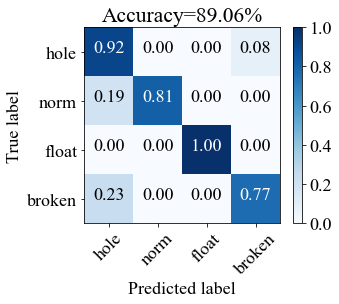

In [4]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(labels.data, preds)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)